# Phase 1 EDA — Turkish System Imbalance

Course-grounded exploration before we start fitting GAMs / LightGBM. Threads:

* **W2 time domain** — ACF/PACF, stationarity, weekly differencing
* **W3 frequency** — periodogram → confirm 24h / 168h / annual peaks
* **Calendar effects** — hour, dow, month, holidays
* **Weather coupling** — net binned by Istanbul + Ankara temperature

The goal is a ranked feature shortlist + a backtest-window decision.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

from src.data import load_imbalance_grid, load_weather, TZ

plt.rcParams['figure.figsize'] = (11, 4)

## 1. Data inventory

In [2]:
grid = load_imbalance_grid(start='2024-01-01')
labeled = grid.dropna(subset=['system_direction'])
print(f"Range:        {grid['dt'].min()}  →  {grid['dt'].max()}")
print(f"Hourly rows:  {len(grid):,}")
print(f"Labeled:      {len(labeled):,}  ({len(labeled)/len(grid):.1%})")
print(f"Latest label: {labeled['dt'].max()}")
print()
print('Class balance:')
print(labeled['system_direction'].value_counts(normalize=True).round(3))

Range:        2024-01-01 00:00:00+03:00  →  2026-05-07 23:00:00+03:00
Hourly rows:  20,592
Labeled:      20,568  (99.9%)
Latest label: 2026-05-07 23:00:00+03:00

Class balance:
system_direction
Negative    0.592
Positive    0.322
Neutral     0.086
Name: proportion, dtype: float64


/var/folders/vl/4kzk3gs53cqf7bfk18xvr3vc0000gn/T/ipykernel_2484/4115884776.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  labeled.assign(month=labeled['dt'].dt.to_period('M'))


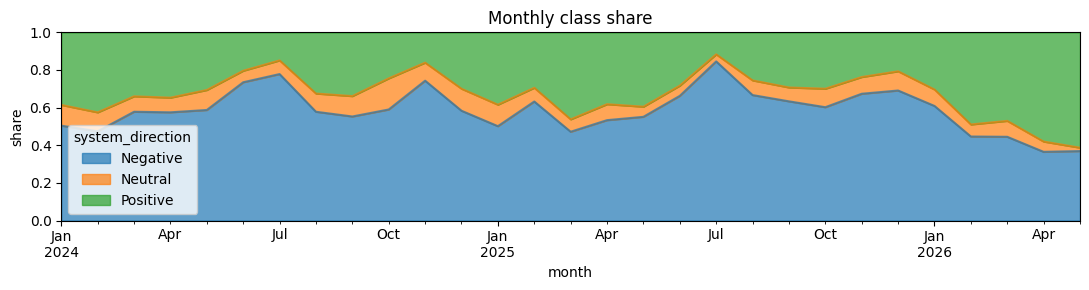

In [3]:
# Class balance over time — has the regime shifted?
monthly = (
    labeled.assign(month=labeled['dt'].dt.to_period('M'))
           .groupby(['month', 'system_direction']).size()
           .unstack(fill_value=0)
)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0)
ax = monthly_pct.plot(kind='area', stacked=True, alpha=0.7, figsize=(11, 3))
ax.set_title('Monthly class share')
ax.set_ylabel('share')
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 2. Distribution of `net`
Where is the mass relative to ±50? Are Neutrals frequent enough to bother predicting?

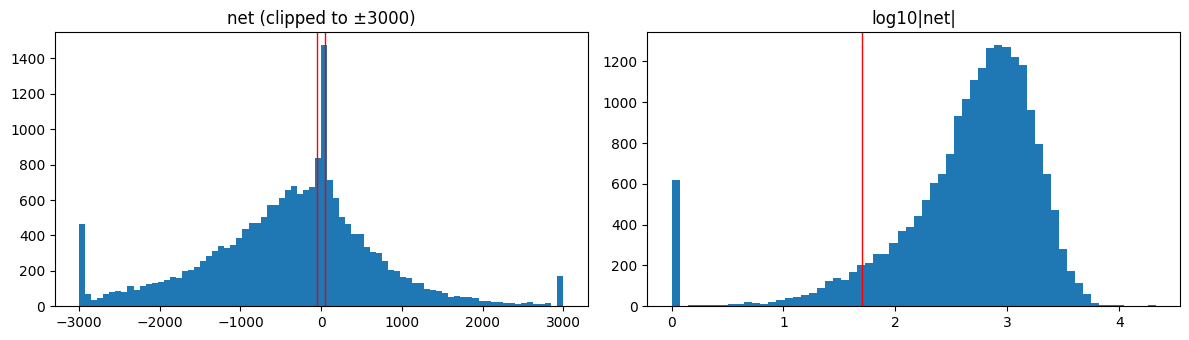

share with |net| ≤ 50 (Neutral):  8.6%
median |net|: 603


In [4]:
net = labeled['net'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(net.clip(-3000, 3000), bins=80)
for x in (-50, 50): axes[0].axvline(x, color='red', linewidth=1)
axes[0].set_title('net (clipped to ±3000)')
axes[1].hist(np.log10(net.abs().clip(lower=1)), bins=60)
axes[1].axvline(np.log10(50), color='red', linewidth=1)
axes[1].set_title('log10|net|')
plt.tight_layout(); plt.show()

near_zero = ((net.abs() <= 50)).mean()
print(f"share with |net| ≤ 50 (Neutral):  {near_zero:.1%}")
print(f"median |net|: {net.abs().median():.0f}")

## 3. W2 — ACF/PACF, stationarity, weekly differencing
Expect ACF spikes at lags 24, 48, 168.

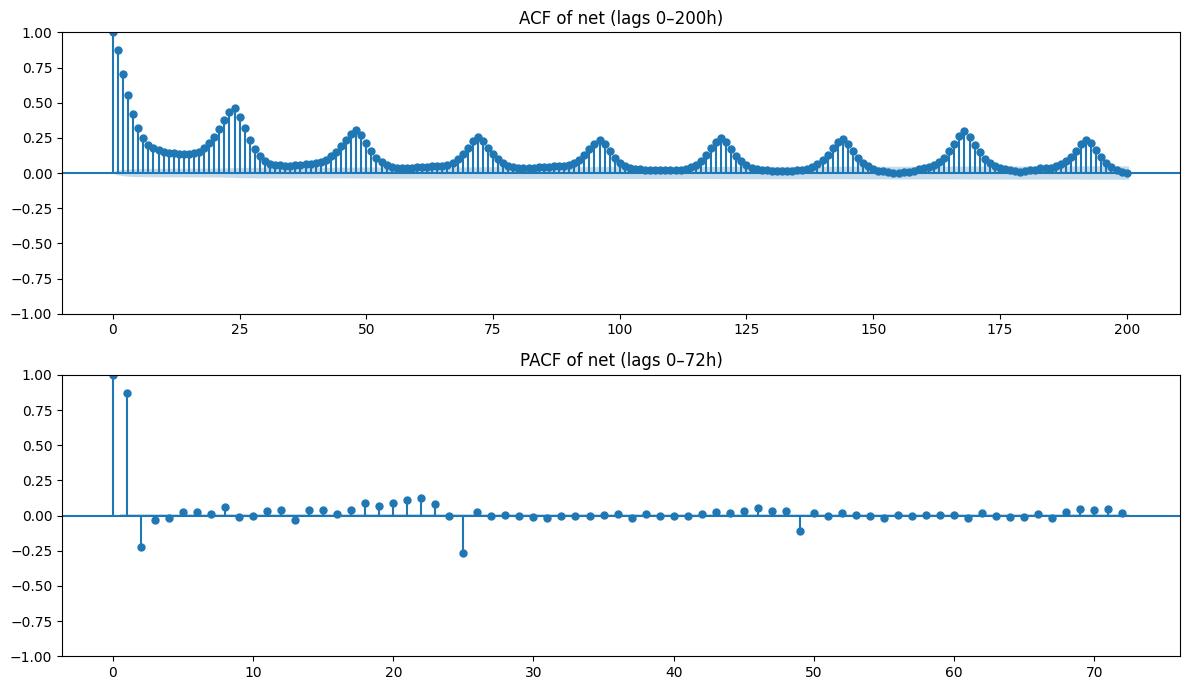

In [5]:
series = grid.set_index('dt')['net'].interpolate(limit=6).dropna()
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(series, lags=200, ax=axes[0])
axes[0].set_title('ACF of net (lags 0–200h)')
plot_pacf(series, lags=72, ax=axes[1], method='ywm')
axes[1].set_title('PACF of net (lags 0–72h)')
plt.tight_layout(); plt.show()

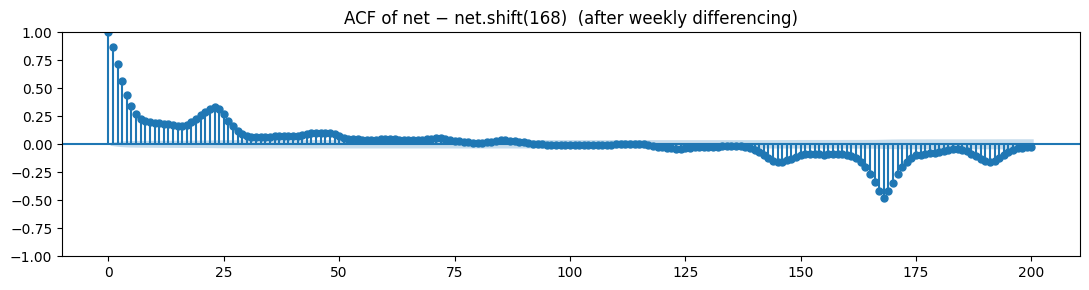

Var(net):        1423571
Var(Δ168 net):   1986926
Reduction:       -39.6%


In [6]:
# Δ168 — weekly differencing should kill most of the seasonal spike
diff168 = (series - series.shift(168)).dropna()
fig, ax = plt.subplots(figsize=(11, 3))
plot_acf(diff168, lags=200, ax=ax)
ax.set_title('ACF of net − net.shift(168)  (after weekly differencing)')
plt.tight_layout(); plt.show()

print('Var(net):       ', round(series.var()))
print('Var(Δ168 net):  ', round(diff168.var()))
print('Reduction:      ', f"{1 - diff168.var()/series.var():.1%}")

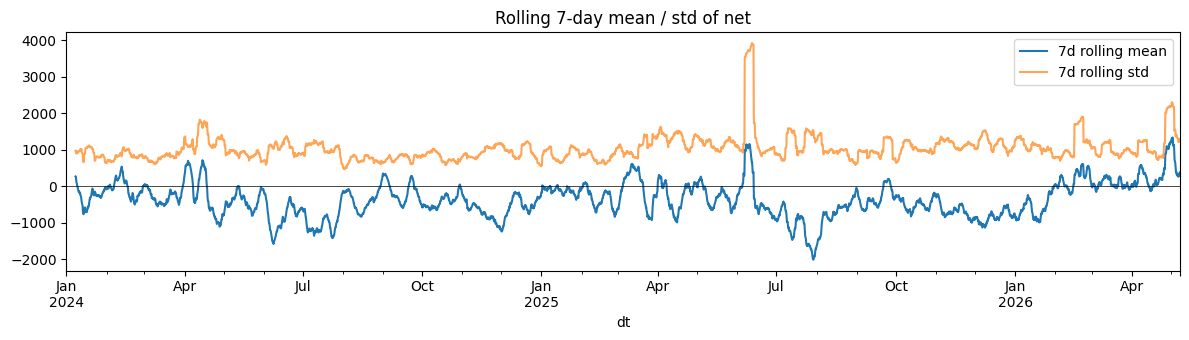

In [7]:
# Rolling stationarity feel
fig, ax = plt.subplots(figsize=(12, 3.5))
series.rolling(24*7).mean().plot(ax=ax, label='7d rolling mean')
series.rolling(24*7).std().plot(ax=ax, label='7d rolling std', alpha=0.7)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title('Rolling 7-day mean / std of net')
ax.legend()
plt.tight_layout(); plt.show()

## 4. W3 — Periodogram
Confirm dominant cycles.

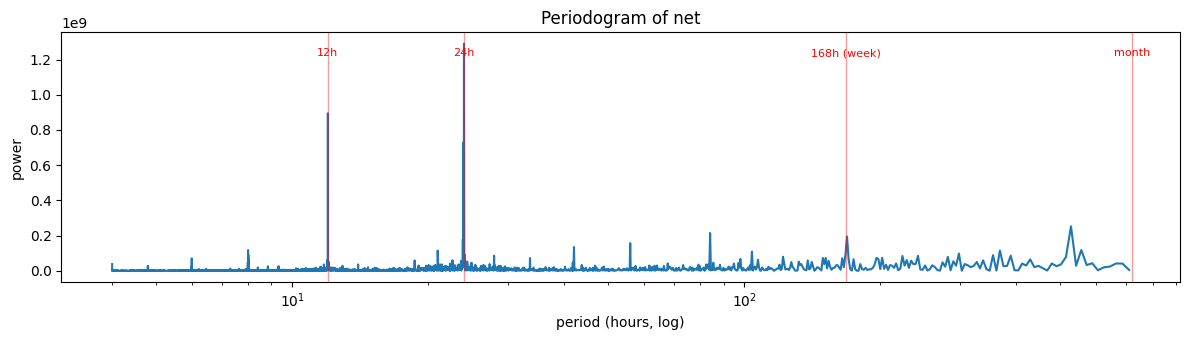

Top 5 peak periods (hours): [ 24.   12.   23.9 528.   84. ]


In [8]:
from scipy.signal import periodogram
freqs, power = periodogram(series.values, fs=1.0)  # 1 sample/hour
periods = np.where(freqs > 0, 1.0 / np.where(freqs > 0, freqs, np.nan), np.nan)

mask = (periods >= 4) & (periods <= 24*30)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.semilogx(periods[mask], power[mask])
for p, lab in [(24, '24h'), (12, '12h'), (168, '168h (week)'), (24*30, 'month')]:
    ax.axvline(p, color='red', alpha=0.4, linewidth=1)
    ax.text(p, ax.get_ylim()[1]*0.9, lab, color='red', fontsize=8, ha='center')
ax.set_xlabel('period (hours, log)')
ax.set_ylabel('power')
ax.set_title('Periodogram of net')
plt.tight_layout(); plt.show()

# top 5 peaks
top_idx = np.argsort(power[mask])[-5:][::-1]
print('Top 5 peak periods (hours):', np.round(periods[mask][top_idx], 1))

## 5. Calendar effects

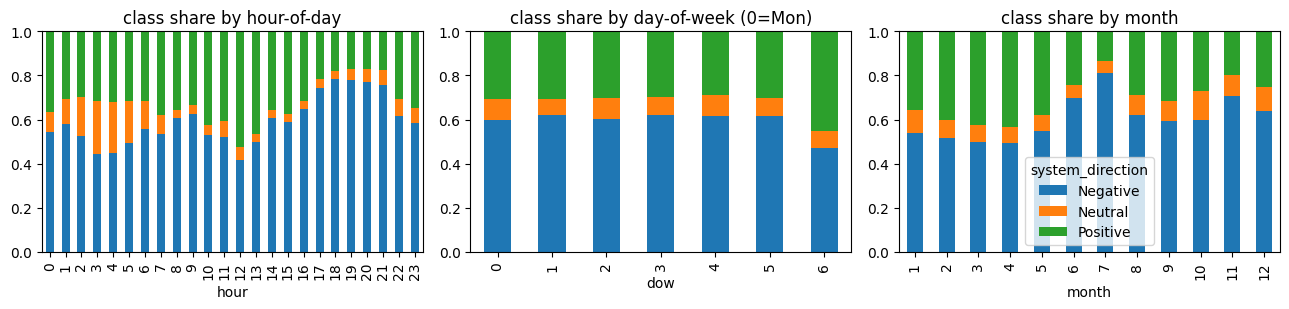

In [9]:
lab = labeled.assign(
    hour=labeled['dt'].dt.hour,
    dow=labeled['dt'].dt.dayofweek,
    month=labeled['dt'].dt.month,
)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col, title in zip(axes, ['hour', 'dow', 'month'], ['hour-of-day', 'day-of-week (0=Mon)', 'month']):
    cls = (lab.groupby([col, 'system_direction']).size().unstack(fill_value=0))
    cls = cls.div(cls.sum(axis=1), axis=0)
    cls.plot(kind='bar', stacked=True, ax=ax, legend=(col == 'month'))
    ax.set_title(f'class share by {title}')
    ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

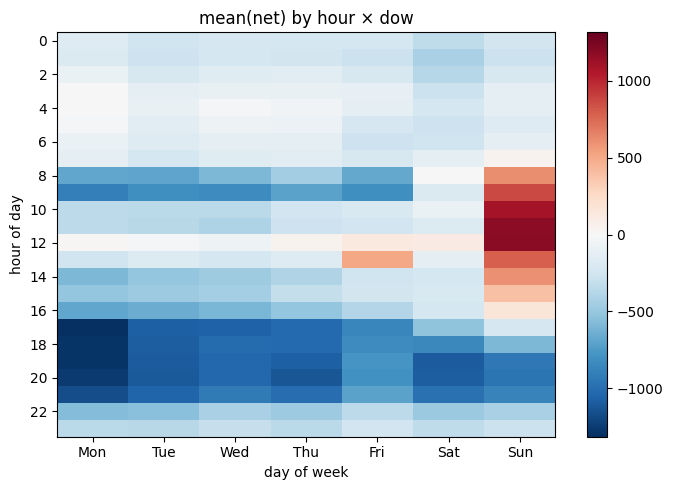

In [10]:
# Mean net by hour × dow heatmap — captures the joint diurnal-weekly cycle
pivot = lab.pivot_table(index='hour', columns='dow', values='net', aggfunc='mean')
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot, aspect='auto', cmap='RdBu_r', vmin=-pivot.abs().values.max(), vmax=pivot.abs().values.max())
ax.set_xticks(range(7)); ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_yticks(range(0, 24, 2))
ax.set_xlabel('day of week'); ax.set_ylabel('hour of day')
ax.set_title('mean(net) by hour × dow')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 6. Weather coupling
Bin `net` by Istanbul + Ankara temperature deciles to check heating/cooling regime.

In [11]:
weather = load_weather(start='2024-01-01')
ist_temp = [c for c in weather.columns if 'location_000' in c and 'temperature' in c][0]
ank_temp = [c for c in weather.columns if 'location_001' in c and 'temperature' in c][0]
merged = weather[['dt', ist_temp, ank_temp]].merge(labeled[['dt', 'net', 'system_direction']], on='dt', how='inner')
merged = merged.rename(columns={ist_temp: 'temp_ist', ank_temp: 'temp_ank'})
merged['temp_avg'] = (merged['temp_ist'] + merged['temp_ank']) / 2
print(f"merged rows: {len(merged):,}")
merged.head()

merged rows: 20,568


,dt,temp_ist,temp_ank,net,system_direction,temp_avg
0,2024-01-01 00:00:00+03:00,9.8545,1.36,1063.32,Positive,5.60725
1,2024-01-01 01:00:00+03:00,10.1045,0.71,44.56,Neutral,5.40725
2,2024-01-01 02:00:00+03:00,10.1045,0.41,0.79,Neutral,5.25725
3,2024-01-01 03:00:00+03:00,9.8545,0.46,103.08,Positive,5.15725
4,2024-01-01 04:00:00+03:00,9.5045,0.26,103.33,Positive,4.88225


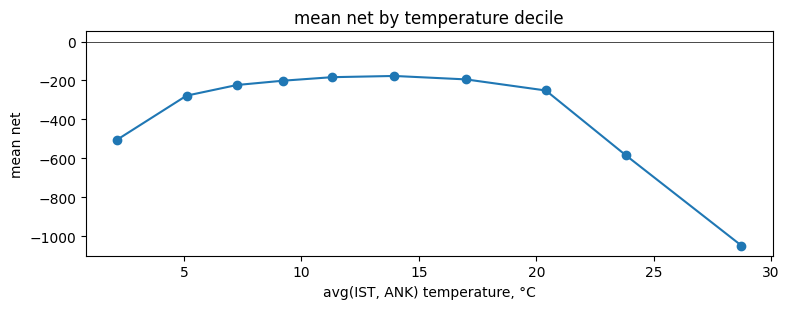

,mean_net,median_temp,n
temp_dec,,,
0,-503.973897,2.157250,2063
1,-278.132651,5.107250,2056
2,-223.251960,7.257250,2056
3,-201.075552,9.232250,2073
4,-183.127355,11.307250,2049
5,-176.873011,13.957251,2046
6,-194.539883,17.007250,2058
7,-251.517607,20.407249,2060
8,-583.760965,23.807251,2052


In [12]:
# Temperature deciles vs mean net
merged['temp_dec'] = pd.qcut(merged['temp_avg'], 10, labels=False)
by_dec = merged.groupby('temp_dec').agg(mean_net=('net','mean'), median_temp=('temp_avg','median'), n=('net','size'))
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(by_dec['median_temp'], by_dec['mean_net'], marker='o')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel('avg(IST, ANK) temperature, °C')
ax.set_ylabel('mean net')
ax.set_title('mean net by temperature decile')
plt.tight_layout(); plt.show()
by_dec

## 7. Lag importance — quick proxy
Correlation of `net` with each lag. Bumps confirm what to feed the GAM/LightGBM.

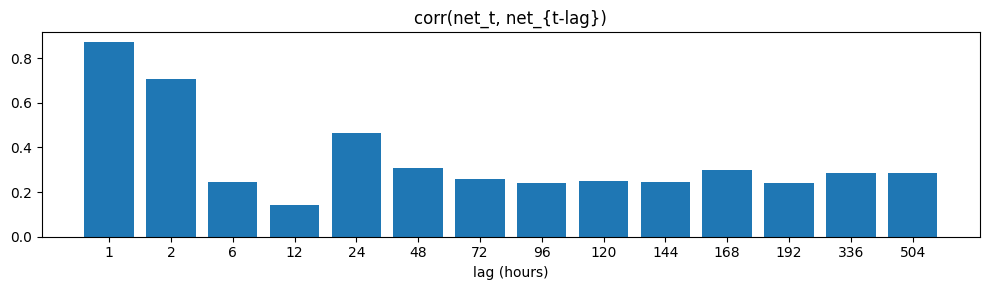

{1: np.float64(0.8724407653313448),
 2: np.float64(0.7070900333844709),
 6: np.float64(0.24736925305394927),
 12: np.float64(0.14291891640259866),
 24: np.float64(0.4649907753061214),
 48: np.float64(0.3071289214684304),
 72: np.float64(0.25938944843583606),
 96: np.float64(0.23914235309621132),
 120: np.float64(0.25141813525161877),
 144: np.float64(0.24473555862355922),
 168: np.float64(0.3006225556538427),
 192: np.float64(0.24104672785912332),
 336: np.float64(0.28649093454504326),
 504: np.float64(0.2845774498053176)}

In [13]:
lags = [1, 2, 6, 12, 24, 48, 72, 96, 120, 144, 168, 192, 336, 504]
corrs = {L: series.corr(series.shift(L)) for L in lags}
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar([str(l) for l in lags], [corrs[l] for l in lags])
ax.set_title('corr(net_t, net_{t-lag})')
ax.set_xlabel('lag (hours)')
plt.tight_layout(); plt.show()
corrs

## Takeaways → feature shortlist for Phase 3

Surprises from the data (vs the original plan):

* **Class balance is heavily skewed:** Negative 59.2% / Positive 32.2% / Neutral 8.6%. Always-Negative is a 59% trivial baseline — our `weather_lr` at 68.8% beats it by ~10pp. Median |net| = 603, so ±50 threshold is tight; the Neutral class is genuinely a thin slice.
* **Week-cycle is weak.** Δ168 differencing *increased* variance by 39.6%, and the periodogram's top peaks are {24, 12, 23.9, 528, 84}h — 168h is **not** in the top 5. `m_seasonal_naive` at 56.5% confirms this: only marginally better than always-Negative.
* **Diurnal (24h) cycle is dominant.** Use `s(hour, bs='cc')` and lag-24 — the strongest safe lag.
* **Lag correlations** (corr(net_t, net_{t-L})): lag-1 0.87, lag-2 0.71 (UNUSABLE — EPIAS delay), lag-6 0.25 (borderline), lag-12 0.14, **lag-24 0.46** (best safe), lag-48 0.31, lag-168 0.30, lag-336 0.29. Plan's emphasis on lag-168/336 was overstated; lag-24 deserves top billing.
* **Weather coupling is U-shaped** (mean_net most negative at coldest decile and hottest decile) → HDD/CDD off 18°C is justified, and `s(temp)` in a GAM should capture this directly.
* **Calendar:** mean(net) by hour×dow heatmap shows clear weekday vs weekend differences in the early-morning hours → keep `hour × is_weekend` interaction.

Phase 3 feature shortlist (revised):

* Calendar: `hour` (cyclic), `dow`, `is_weekend`, `month`, `doy` (cyclic for annual)
* Lags: `net_lag_24, net_lag_48, net_lag_72, net_lag_168, net_lag_336`
* Weather: `temp_avg`, `HDD = max(0, 18 - temp)`, `CDD = max(0, temp - 18)` per Istanbul/Ankara/Izmir; `humidity_avg`, `wind_avg`, `cloud_avg`
* Interactions: `hour × is_weekend`, `temp_avg × hour`
* Skip lags ≤ 12 due to EPIAS publish delay.